<a href="https://colab.research.google.com/github/parimal173/DIY_MRI_DLapproches/blob/main/Day_3_Notebook_1_2_ZSSR_LF_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1.2 — ZSSR: Controlled Synthetic Test → Real 64 mT MRI

## Workshop objective

This notebook has **two deliberately separate experiments**.

    ### Experiment A — Controlled ZSSR experiment

    Start with a known high-resolution (HR) image:

    **HR = 224 × 224**

    Then create:

    **LR = HR downsampled ×2 = 112 × 112**

    Next create an even smaller image:

    **LLR = LR downsampled ×2 = 56 × 56**

    The ZSSR CNN learns only from the internal pair:

    **LLR (56 × 56) → LR (112 × 112)**

    After training, we apply the learned CNN to:

    **LR (112 × 112) → predicted HR (224 × 224)**

    Because the original HR image is known, we can compare:

    **Bicubic vs ZSSR vs HR**

    using **PSNR and SSIM**.

---

    ### Experiment B — Real 64 mT low-field MRI

    After students understand the controlled experiment, we use an actual 64 mT MRI slice:

    **64 mT slice = real LR image**

    We create an internal smaller image:

    **64 mT LLR = 64 mT LR downsampled ×2**

    The CNN learns:

    **LLR → 64 mT LR**

    Then we perform:

    **64 mT LR → ZSSR → enhanced 64 mT SR**

    This is the important conceptual distinction:

    > In Experiment A, HR is known, so we can measure reconstruction quality directly.
    >
    > In Experiment B, the 64 mT image is the real low-field input. The 3T image is **not used as the ZSSR training target**. It can only be used for evaluation after appropriate registration/harmonization.

### Why this structure?

    Students first learn ZSSR where the ground truth is controlled. Then the same pipeline is transferred to real low-field MRI without accidentally mixing the 3T reference into the self-supervised training process.


# Module 0 — Imports and configuration

We use a small CNN so that every stage of the ZSSR process remains visible and understandable.

The notebook uses **×2 super-resolution** throughout the first experiment. The same functions can later be generalized to ×3 or ×4.


In [ ]:
# from google.colab import drive
# drive.mount('/drive')

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).


In [1]:
!git clone https://github.com/ajaynice1996/DIY_MRI_Workshop_II_Recon

Cloning into 'DIY_MRI_Workshop_II_Recon'...
remote: Enumerating objects: 293, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 293 (delta 15), reused 8 (delta 8), pack-reused 265 (from 1)
Receiving objects: 100% (293/293), 177.11 MiB | 19.36 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Updating files: 100% (99/99), done.


In [2]:
import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SCALE = 2
PATCH_SIZE = 16
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-3

print("Device:", DEVICE)
print("Super-resolution scale:", SCALE)


Device: cpu
Super-resolution scale: 2


# Module 1 — Load the workshop MRI data

We load both volumes using the workshop directory structure.

- **3T MRI:** available as a potential high-quality reference.
- **64 mT MRI:** the real low-field image that will eventually be processed by ZSSR.

At this stage we only inspect the data. We do **not** train anything yet.


In [3]:
workshop_dir = "/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/"

In [4]:
# ============================================================
# 1. Load 3T MRI
# ============================================================

path_3T = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T2.nii.gz"
)

print("Loading 3T:", path_3T)

nii_3T = nib.load(path_3T)
mri_3T = nii_3T.get_fdata().astype(np.float32)


# ============================================================
# 2. Load 64 mT MRI
# ============================================================

path_64mT = os.path.join(
    workshop_dir,
    "64mT",
    "POCEMR001_T2.nii.gz"
)

print("Loading 64 mT:", path_64mT)

nii_64mT = nib.load(path_64mT)
mri_64mT = nii_64mT.get_fdata().astype(np.float32)


# ============================================================
# 3. Print information
# ============================================================

print("\n" + "=" * 60)
print("3T MRI")
print("=" * 60)

print("Shape:", mri_3T.shape)
print("Voxel spacing:", nii_3T.header.get_zooms()[:3])
print("Data type:", mri_3T.dtype)
print("Minimum intensity:", mri_3T.min())
print("Maximum intensity:", mri_3T.max())
print("Mean intensity:", mri_3T.mean())
print("Standard deviation:", mri_3T.std())


print("\n" + "=" * 60)
print("64 mT Low-Field MRI")
print("=" * 60)

print("Shape:", mri_64mT.shape)
print("Voxel spacing:", nii_64mT.header.get_zooms()[:3])
print("Data type:", mri_64mT.dtype)
print("Minimum intensity:", mri_64mT.min())
print("Maximum intensity:", mri_64mT.max())
print("Mean intensity:", mri_64mT.mean())
print("Standard deviation:", mri_64mT.std())


Loading 3T: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/3T/POCEMR001_T2.nii.gz
Loading 64 mT: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/64mT/POCEMR001_T2.nii.gz

3T MRI
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 38.78939
Standard deviation: 53.17793

64 mT Low-Field MRI
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 44.35543
Standard deviation: 56.47321


# Module 2 — Normalize MRI intensity

For this teaching notebook we use robust percentile normalization.

MRI intensity is not a universal physical scale, so normalization is a computational preprocessing step. It should not be interpreted as scanner calibration.


In [5]:
def robust_normalize(volume, low=1, high=99):
    lo, hi = np.percentile(volume, [low, high])
    volume = np.clip(volume, lo, hi)
    return ((volume - lo) / (hi - lo + 1e-8)).astype(np.float32)


mri_3T_n = robust_normalize(mri_3T)
mri_64mT_n = robust_normalize(mri_64mT)

print("3T normalized range:", mri_3T_n.min(), "to", mri_3T_n.max())
print("64 mT normalized range:", mri_64mT_n.min(), "to", mri_64mT_n.max())


3T normalized range: 0.0 to 1.0
64 mT normalized range: 0.0 to 1.0


# ============================================================
# EXPERIMENT A
# CONTROLLED SYNTHETIC ZSSR EXPERIMENT
# ============================================================

# Module 3 — Select a high-resolution 3T slice

Here we intentionally create a **known HR image** from the 3T volume.

This is the cleanest environment for learning ZSSR because we know what the desired HR image is.

We will crop/resize one 3T slice to exactly **224 × 224**.

### Pipeline

```text
3T HR slice
    │
    ▼
224 × 224 HR
    │
    └── downsample ×2 ──> 112 × 112 LR
                              │
                              └── downsample ×2 ──> 56 × 56 LLR
```

The ZSSR model will learn:

```text
56 × 56 LLR  →  112 × 112 LR
```

Then inference will be:

```text
112 × 112 LR  →  224 × 224 ZSSR-HR
```


Selected slice: 80
HR teaching image: (224, 224)


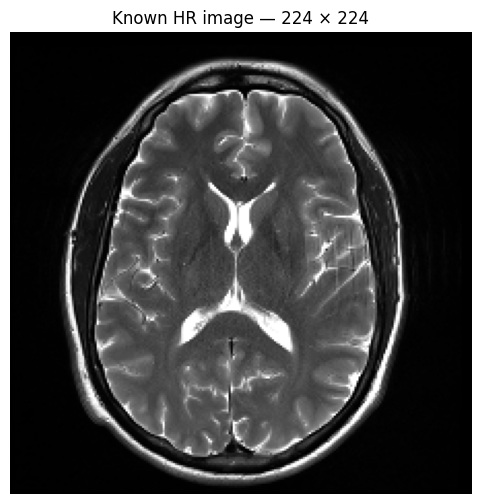

In [6]:
SLICE_INDEX = mri_3T_n.shape[2] // 2

hr_source = mri_3T_n[:, :, SLICE_INDEX]

# Force a clean 224 x 224 HR teaching image.
HR_SIZE = (224, 224)

hr = resize(
    hr_source,
    HR_SIZE,
    order=3,
    mode="reflect",
    anti_aliasing=True,
    preserve_range=True
).astype(np.float32)

print("Selected slice:", SLICE_INDEX)
print("HR teaching image:", hr.shape)

plt.figure(figsize=(6, 6))
plt.imshow(hr.T, cmap="gray", origin="lower")
plt.title("Known HR image — 224 × 224")
plt.axis("off")
plt.show()


# Module 4 — Create LR and LLR

Now we deliberately degrade the known HR image.

### Definitions

**HR**

224 × 224

**LR**

112 × 112

**LLR**

56 × 56

Mathematically:

\[
LR = D_2(HR)
\]

\[
LLR = D_2(LR)
\]

The important point is that **LR is the image we pretend is the observed low-resolution image**.

The CNN never sees HR during ZSSR training.


HR : (224, 224)
LR : (112, 112)
LLR: (56, 56)


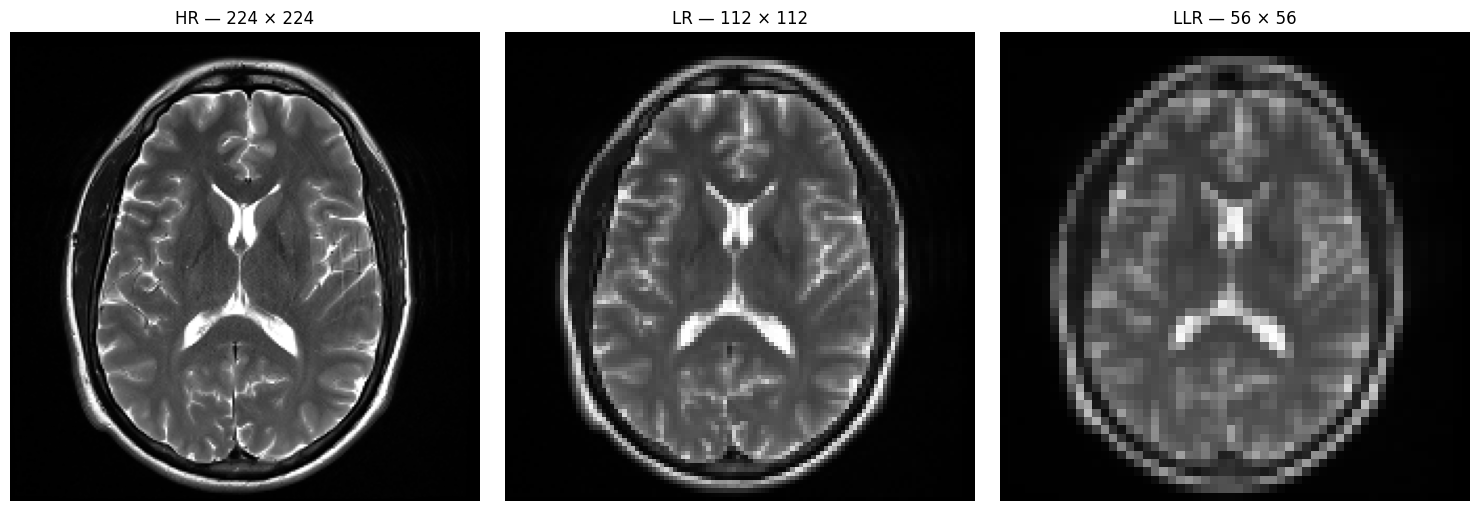

In [7]:
def downsample(image, scale=2, order=1):
    h, w = image.shape
    return resize(
        image,
        (h // scale, w // scale),
        order=order,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True
    ).astype(np.float32)


def upsample(image, target_shape, order=3):
    return resize(
        image,
        target_shape,
        order=order,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True
    ).astype(np.float32)


lr = downsample(hr, SCALE, order=1)
llr = downsample(lr, SCALE, order=1)

print("HR :", hr.shape)
print("LR :", lr.shape)
print("LLR:", llr.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(hr.T, cmap="gray", origin="lower")
axes[0].set_title("HR — 224 × 224")

axes[1].imshow(lr.T, cmap="gray", origin="lower")
axes[1].set_title("LR — 112 × 112")

axes[2].imshow(llr.T, cmap="gray", origin="lower")
axes[2].set_title("LLR — 56 × 56")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Module 5 — Baseline: Bicubic LR → HR

Before ZSSR, we establish the baseline.

We use the **112 × 112 LR image** and simply interpolate it to **224 × 224**.

```text
LR 112 × 112
      │
      ▼
Bicubic interpolation
      │
      ▼
224 × 224
```

There is no learning.

This gives students a direct question:

> Can a CNN trained only on the internal information of the image improve over interpolation?


Bicubic PSNR: 24.736 dB
Bicubic SSIM: 0.9012


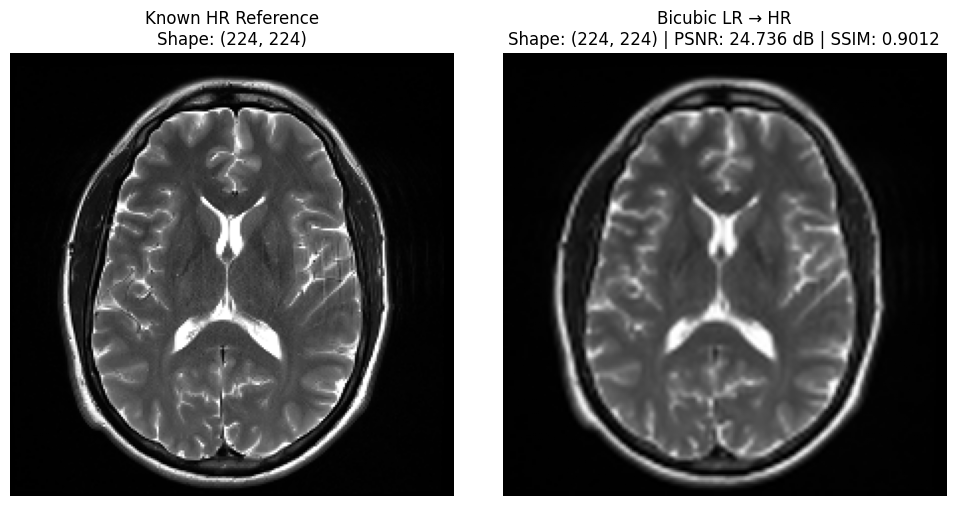

In [8]:
bicubic_sr = upsample(lr, hr.shape, order=3)

psnr_bicubic = peak_signal_noise_ratio(
    hr, bicubic_sr, data_range=1.0
)

ssim_bicubic = structural_similarity(
    hr, bicubic_sr, data_range=1.0
)

print(f"Bicubic PSNR: {psnr_bicubic:.3f} dB")
print(f"Bicubic SSIM: {ssim_bicubic:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(hr.T, cmap="gray", origin="lower")
axes[0].set_title(
    f"Known HR Reference\n"
    f"Shape: {hr.shape}"
)

axes[1].imshow(bicubic_sr.T, cmap="gray", origin="lower")
axes[1].set_title(
    f"Bicubic LR → HR\n"
    f"Shape: {bicubic_sr.shape} | "
    f"PSNR: {psnr_bicubic:.3f} dB | "
    f"SSIM: {ssim_bicubic:.4f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Module 6 — Build the internal ZSSR training set

This is the central ZSSR step.

We **do not** create a training set using external images.

Instead:

```text
LLR 56 × 56  →  LR 112 × 112
```

is used to create many corresponding local training examples.

For each patch:

```text
input  = patch from LLR
target = corresponding patch from LR
```

For ×2 SR:

- input patch = 16 × 16
- target patch = 32 × 32

This teaches the CNN the internal image-specific scale relationship.


In [9]:
def extract_training_patches(
    low_image,
    target_image,
    patch_size=16,
    scale=2,
    stride=4,
    max_patches=5000
):
    target_patch_size = patch_size * scale

    inputs = []
    targets = []

    max_y = low_image.shape[0] - patch_size + 1
    max_x = low_image.shape[1] - patch_size + 1

    for y in range(0, max_y, stride):
        for x in range(0, max_x, stride):

            x_patch = low_image[
                y:y + patch_size,
                x:x + patch_size
            ]

            y_patch = target_image[
                y * scale:y * scale + target_patch_size,
                x * scale:x * scale + target_patch_size
            ]

            if y_patch.shape == (target_patch_size, target_patch_size):
                inputs.append(x_patch)
                targets.append(y_patch)

    if len(inputs) == 0:
        raise ValueError("No patches generated. Reduce PATCH_SIZE.")

    indices = np.arange(len(inputs))
    np.random.shuffle(indices)
    indices = indices[:max_patches]

    X = np.stack([inputs[i] for i in indices])[:, None]
    Y = np.stack([targets[i] for i in indices])[:, None]

    return X.astype(np.float32), Y.astype(np.float32)


X_np, Y_np = extract_training_patches(
    llr,
    lr,
    patch_size=PATCH_SIZE,
    scale=SCALE
)

print("Training input patches :", X_np.shape)
print("Training target patches:", Y_np.shape)


Training input patches : (121, 1, 16, 16)
Training target patches: (121, 1, 32, 32)


# Module 7 — Understand one training example

Before training the network, visualize one pair.

The network sees:

**Son patch → Father patch**

It never receives the original 224 × 224 HR image during training.


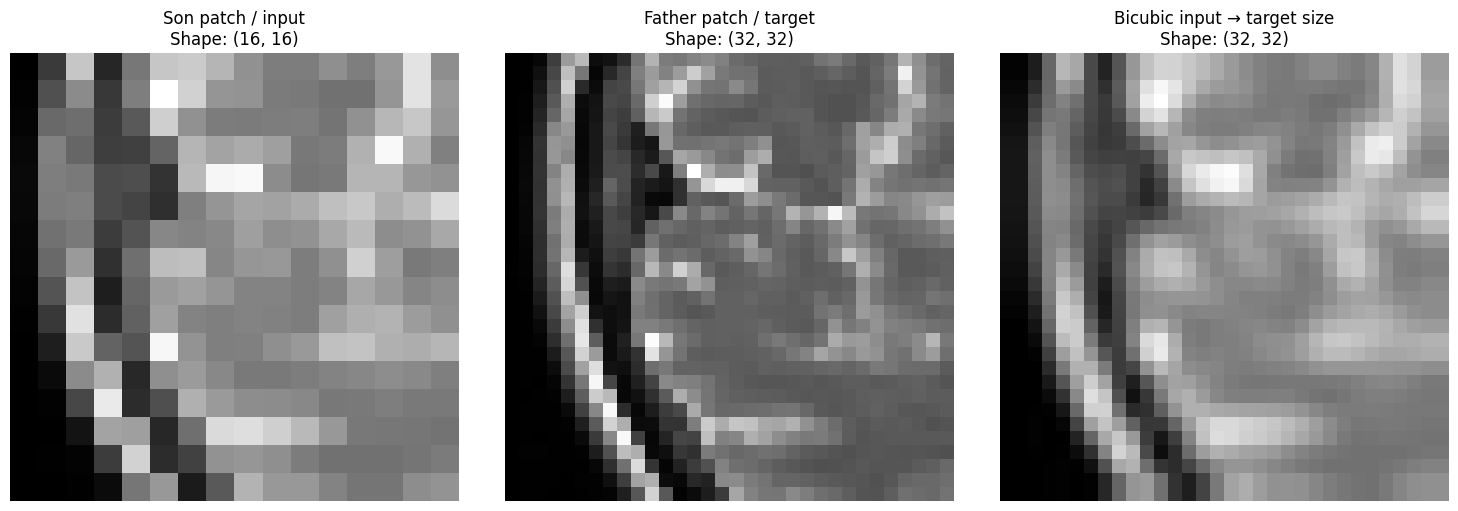

In [10]:
example_index = 0

example_input = X_np[example_index, 0]
example_target = Y_np[example_index, 0]

example_input_up = upsample(
    example_input,
    example_target.shape,
    order=3
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(example_input, cmap="gray", origin="lower")
axes[0].set_title(
    f"Son patch / input\nShape: {example_input.shape}"
)

axes[1].imshow(example_target, cmap="gray", origin="lower")
axes[1].set_title(
    f"Father patch / target\nShape: {example_target.shape}"
)

axes[2].imshow(example_input_up, cmap="gray", origin="lower")
axes[2].set_title(
    f"Bicubic input → target size\nShape: {example_input_up.shape}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Module 8 — Small ZSSR CNN

We use a simple residual CNN.

The network first upsamples the input using bicubic interpolation. The CNN then learns a residual correction.

```text
Son patch
   ↓
Bicubic ×2
   ↓
CNN refinement
   ↓
Predicted Father patch
```

This design makes the comparison with bicubic especially clear.


In [11]:
class SimpleZSSR(nn.Module):

    def __init__(self, scale=2):
        super().__init__()

        self.scale = scale

        self.refine = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, x):

        base = F.interpolate(
            x,
            scale_factor=self.scale,
            mode="bicubic",
            align_corners=False
        )

        residual = self.refine(base)

        return torch.clamp(base + residual, 0.0, 1.0)


model = SimpleZSSR(scale=SCALE).to(DEVICE)

print(model)

# Total number of parameters
total_params = sum(p.numel() for p in model.parameters())

# Trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


SimpleZSSR(
  (refine): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

Total parameters: 56,321
Trainable parameters: 56,321


# Module 9 — Train ZSSR on the internal LLR → LR relationship

This is the **zero-shot learning stage**.

The model learns:

\[
f_\theta(LLR) \approx LR
\]

using only patches extracted from the same image.

There is no external training dataset.


In [12]:
X = torch.from_numpy(X_np)
Y = torch.from_numpy(Y_np)

loader = DataLoader(
    TensorDataset(X, Y),
    batch_size=BATCH_SIZE,
    shuffle=True
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


Epoch   1/100 | MSE: 0.005777
Epoch  10/100 | MSE: 0.003169
Epoch  20/100 | MSE: 0.002563
Epoch  30/100 | MSE: 0.002221
Epoch  40/100 | MSE: 0.001978
Epoch  50/100 | MSE: 0.001783
Epoch  60/100 | MSE: 0.001624
Epoch  70/100 | MSE: 0.001499
Epoch  80/100 | MSE: 0.001395
Epoch  90/100 | MSE: 0.001308
Epoch 100/100 | MSE: 0.001223


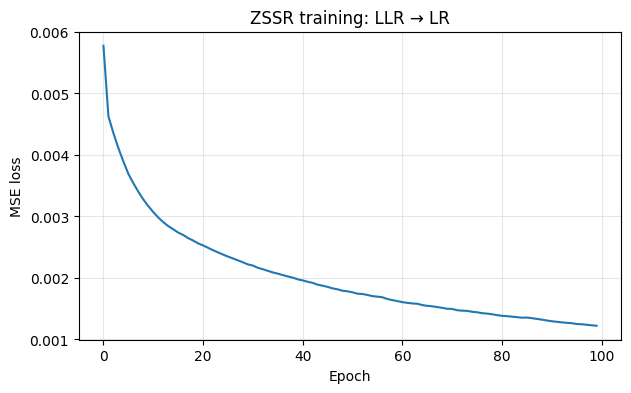

In [13]:

loss_history = []

model.train()

for epoch in range(EPOCHS):

    running_loss = 0.0

    for xb, yb in loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        prediction = model(xb)

        loss = criterion(prediction, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"MSE: {epoch_loss:.6f}"
        )

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("ZSSR training: LLR → LR")
plt.grid(alpha=0.3)
plt.show()


# Module 10 — Inference: LR → predicted HR

Now comes the key ZSSR step.

The CNN has learned:

```text
LLR 56 × 56 → LR 112 × 112
```

We now apply the same learned relationship one scale higher:

```text
LR 112 × 112 → predicted HR 224 × 224
```

The original HR image is used **only for evaluation**, not as an inference input.


In [14]:
def zssr_inference(model, image, scale=2, device=DEVICE):
    model.eval()

    x = torch.from_numpy(
        image[None, None]
    ).float().to(device)

    with torch.no_grad():
        sr = model(x)

    return np.clip(
        sr.cpu().numpy()[0, 0],
        0,
        1
    )


zssr_sr = zssr_inference(
    model,
    lr,
    scale=SCALE
)

print("LR input:", lr.shape)
print("ZSSR output:", zssr_sr.shape)


LR input: (112, 112)
ZSSR output: (224, 224)


# Module 11 — Main controlled comparison

This is the main result of Experiment A.

We compare:

1. **Known HR**
2. **Bicubic LR → HR**
3. **ZSSR LR → HR**

The expected question is:

> Does the image-specific CNN improve PSNR and/or SSIM over bicubic interpolation?

The actual result must be measured; it should not be assumed in advance.


In [15]:
psnr_zssr = peak_signal_noise_ratio(
    hr,
    zssr_sr,
    data_range=1.0
)

ssim_zssr = structural_similarity(
    hr,
    zssr_sr,
    data_range=1.0
)

print("=" * 60)
print("CONTROLLED HR → LR → SR RESULTS")
print("=" * 60)
print(f"Bicubic : PSNR = {psnr_bicubic:.3f} dB | SSIM = {ssim_bicubic:.4f}")
print(f"ZSSR    : PSNR = {psnr_zssr:.3f} dB | SSIM = {ssim_zssr:.4f}")
print(f"Δ PSNR  : {psnr_zssr - psnr_bicubic:+.3f} dB")
print(f"Δ SSIM  : {ssim_zssr - ssim_bicubic:+.4f}")


CONTROLLED HR → LR → SR RESULTS
Bicubic : PSNR = 24.736 dB | SSIM = 0.9012
ZSSR    : PSNR = 26.403 dB | SSIM = 0.9195
Δ PSNR  : +1.667 dB
Δ SSIM  : +0.0182


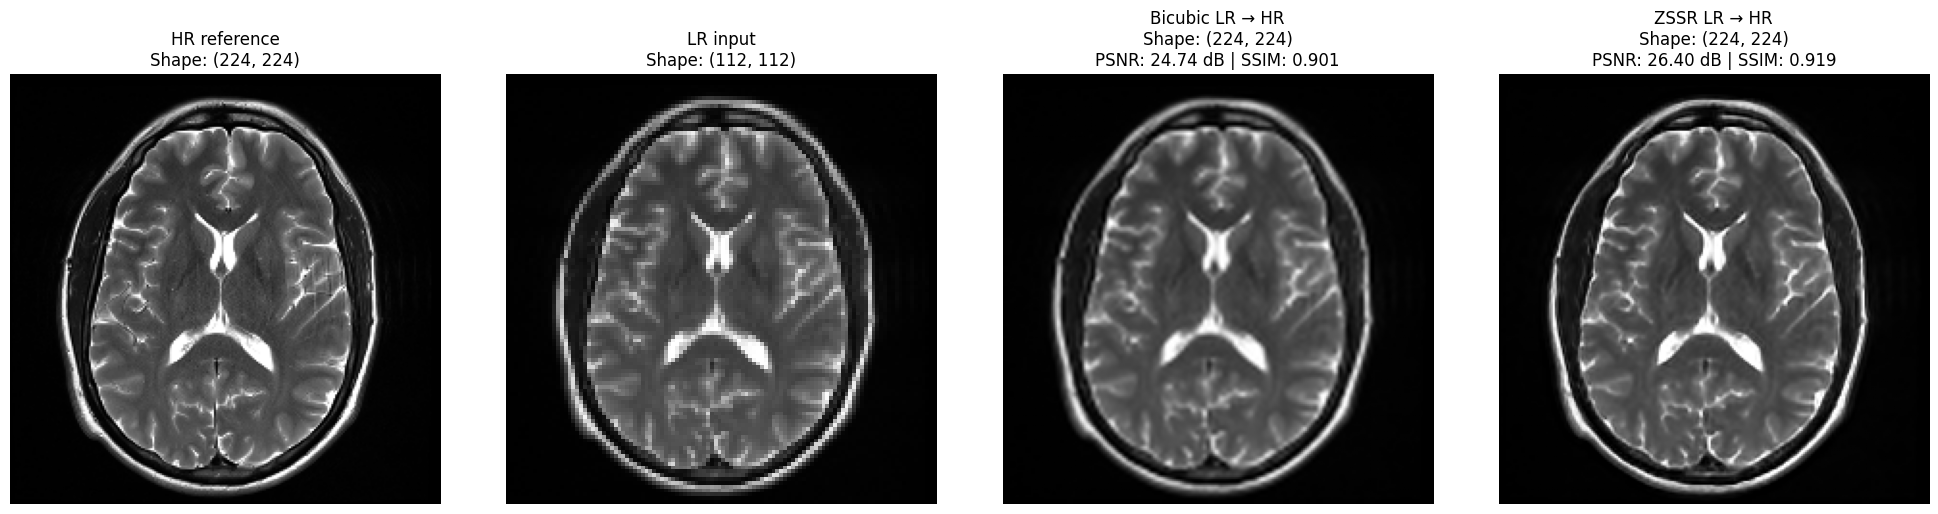

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(hr.T, cmap="gray", origin="lower")
axes[0].set_title(
    f"HR reference\n"
    f"Shape: {hr.shape}"
)

axes[1].imshow(lr.T, cmap="gray", origin="lower")
axes[1].set_title(
    f"LR input\n"
    f"Shape: {lr.shape}"
)

axes[2].imshow(bicubic_sr.T, cmap="gray", origin="lower")
axes[2].set_title(
    f"Bicubic LR → HR\n"
    f"Shape: {bicubic_sr.shape}\n"
    f"PSNR: {psnr_bicubic:.2f} dB | SSIM: {ssim_bicubic:.3f}"
)

axes[3].imshow(zssr_sr.T, cmap="gray", origin="lower")
axes[3].set_title(
    f"ZSSR LR → HR\n"
    f"Shape: {zssr_sr.shape}\n"
    f"PSNR: {psnr_zssr:.2f} dB | SSIM: {ssim_zssr:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Module 12 — Error maps

PSNR and SSIM provide numerical measurements, but students should also inspect where the reconstruction differs from the reference.

We calculate:

\[
Error = |HR - SR|
\]

Compare the error maps for bicubic and ZSSR.


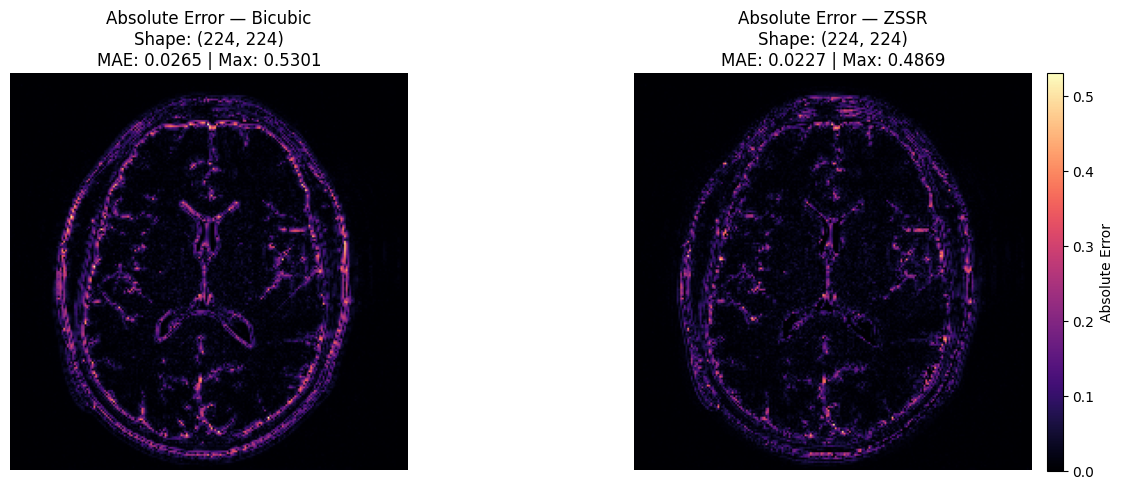

In [17]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

error_bicubic = np.abs(hr - bicubic_sr)
error_zssr = np.abs(hr - zssr_sr)

# Common scale for fair comparison
vmax = max(error_bicubic.max(), error_zssr.max())

# Summary statistics
mae_bicubic = np.mean(error_bicubic)
mae_zssr = np.mean(error_zssr)

max_bicubic = np.max(error_bicubic)
max_zssr = np.max(error_zssr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Bicubic error
# ---------------------------------------------------------

im0 = axes[0].imshow(
    error_bicubic.T,
    cmap="magma",
    origin="lower",
    vmin=0,
    vmax=vmax
)

axes[0].set_title(
    f"Absolute Error — Bicubic\n"
    f"Shape: {error_bicubic.shape}\n"
    f"MAE: {mae_bicubic:.4f} | Max: {max_bicubic:.4f}"
)

axes[0].axis("off")


# ---------------------------------------------------------
# ZSSR error
# ---------------------------------------------------------

im1 = axes[1].imshow(
    error_zssr.T,
    cmap="magma",
    origin="lower",
    vmin=0,
    vmax=vmax
)

axes[1].set_title(
    f"Absolute Error — ZSSR\n"
    f"Shape: {error_zssr.shape}\n"
    f"MAE: {mae_zssr:.4f} | Max: {max_zssr:.4f}"
)

axes[1].axis("off")


# ---------------------------------------------------------
# Dedicated colorbar axis
# ---------------------------------------------------------

divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.15
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label("Absolute Error")


plt.tight_layout()
plt.show()

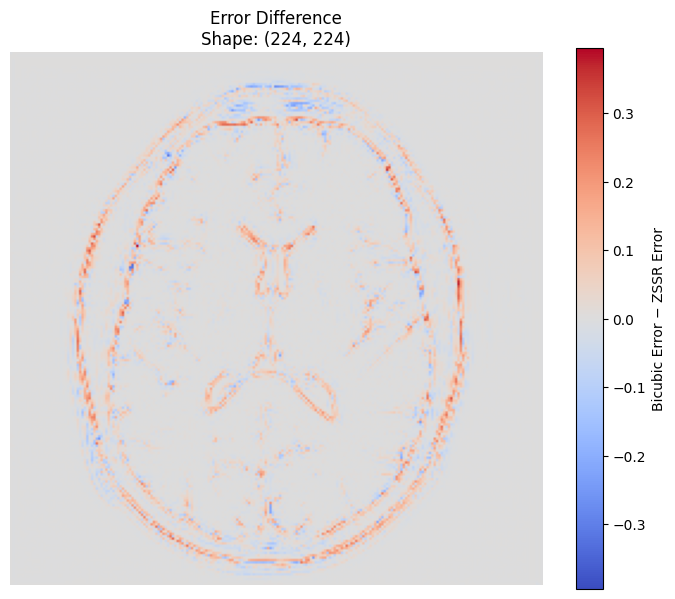

In [18]:
error_difference = error_bicubic - error_zssr

plt.figure(figsize=(7, 6))

v = np.max(np.abs(error_difference))

plt.imshow(
    error_difference.T,
    cmap="coolwarm",
    origin="lower",
    vmin=-v,
    vmax=v
)

plt.colorbar(label="Bicubic Error − ZSSR Error")

plt.title(
    f"Error Difference\n"
    f"Shape: {error_difference.shape}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

# Module 13 — What did we actually learn?

The controlled experiment establishes the complete ZSSR logic:

```text
KNOWN HR
  │
  └── downsample ×2
          ↓
       LR 112
          │
          └── downsample ×2
                  ↓
              LLR 56
                  │
                  ▼
            Train CNN
          LLR → LR
                  │
                  ▼
        Apply CNN to LR
          LR → predicted HR
                  │
                  ▼
        Compare with known HR
```

### The critical point

The CNN did **not** learn:

```text
3T image → 64 mT image
```

and it did **not** learn from a population of MRI subjects.

It learned an **internal scale relationship from one image**.


# ============================================================
# EXPERIMENT B
# APPLY THE SAME IDEA TO A TRUE 64 mT MRI SLICE
# ============================================================

# Module 14 — Select a real 64 mT slice

Now we leave the synthetic experiment.

The selected 64 mT slice is the actual low-field input.

We call it **real LR** because it represents the image that we want to enhance.

```text
REAL 64 mT slice
      ↓
    LR
```

We will create an internal lower-resolution version:

```text
REAL 64 mT LR
      ↓ downsample ×2
64 mT LLR
```

Then train:

```text
64 mT LLR → 64 mT LR
```

and infer:

```text
64 mT LR → 64 mT ZSSR-SR
```


64 mT slice index: 80
64 mT LR shape: (224, 224)


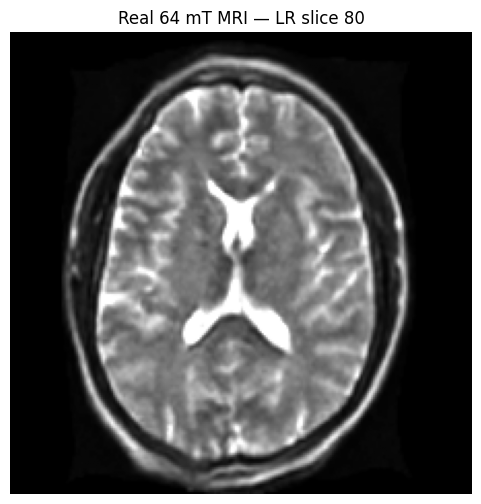

In [27]:
LF_SLICE_INDEX = mri_64mT_n.shape[2] // 2

lf_hr = mri_64mT_n[:, :, LF_SLICE_INDEX]

print("64 mT slice index:", LF_SLICE_INDEX)
print("64 mT LR shape:", lf_hr.shape)

plt.figure(figsize=(6, 6))
plt.imshow(lf_hr.T, cmap="gray", origin="lower")
plt.title(f"Real 64 mT MRI — LR slice {LF_SLICE_INDEX}")
plt.axis("off")
plt.show()


# Module 15 — Create the internal 64 mT LLR image

We repeat the exact ZSSR construction used in Experiment A.

```text
Real 64 mT LR
      │
      ▼
downsample ×2
      │
      ▼
64 mT LLR
```

This creates the internal training pair:

```text
64 mT LLR → 64 mT LR
```

Notice that the 3T image has not entered this training process.


64 mT slice index: 80
64 mT HR/reference shape: (224, 224)
64 mT HR : (224, 224)
64 mT LR : (112, 112)
64 mT LLR: (56, 56)


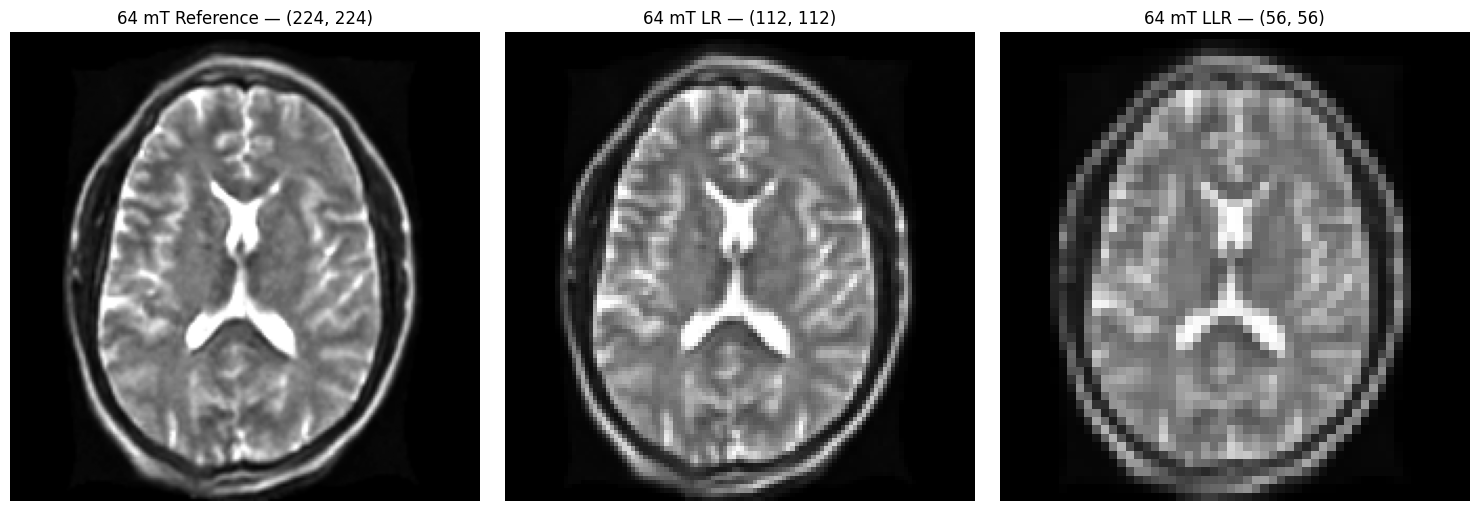

In [30]:
# ---------------------------------------------------------
# Real 64 mT slice — reference resolution
# ---------------------------------------------------------

LF_SLICE_INDEX = mri_64mT_n.shape[2] // 2

lf_hr = mri_64mT_n[:, :, LF_SLICE_INDEX]

print("64 mT slice index:", LF_SLICE_INDEX)
print("64 mT HR/reference shape:", lf_hr.shape)


# ---------------------------------------------------------
# Create synthetic LR versions
# 224 x 224 -> 112 x 112 -> 56 x 56
# ---------------------------------------------------------

lf_lr = downsample(
    lf_hr,
    SCALE,
    order=1
)

lf_llr = downsample(
    lf_lr,
    SCALE,
    order=1
)

print("64 mT HR :", lf_hr.shape)
print("64 mT LR :", lf_lr.shape)
print("64 mT LLR:", lf_llr.shape)


# ---------------------------------------------------------
# Visualize all three resolutions
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    lf_hr.T,
    cmap="gray",
    origin="lower"
)
axes[0].set_title(f"64 mT Reference — {lf_hr.shape}")

axes[1].imshow(
    lf_lr.T,
    cmap="gray",
    origin="lower"
)
axes[1].set_title(f"64 mT LR — {lf_lr.shape}")

axes[2].imshow(
    lf_llr.T,
    cmap="gray",
    origin="lower"
)
axes[2].set_title(f"64 mT LLR — {lf_llr.shape}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Module 16 — Train a fresh ZSSR model on the real 64 mT slice

For a true ZSSR experiment, we train a **new model for this image**.

The training pair is:

```text
Input  = 64 mT LLR
Target = 64 mT LR
```

The 3T scan is not used to construct the target.


In [31]:
X_lf_np, Y_lf_np = extract_training_patches(
    lf_lr,
    lf_hr,
    patch_size=PATCH_SIZE,
    scale=SCALE
)
# Not using double downsampled images
print("64 mT input patches :", X_lf_np.shape)
print("64 mT target patches:", Y_lf_np.shape)

64 mT input patches : (625, 1, 16, 16)
64 mT target patches: (625, 1, 32, 32)


In [32]:
lf_model = SimpleZSSR(scale=SCALE).to(DEVICE)

lf_X = torch.from_numpy(X_lf_np)
lf_Y = torch.from_numpy(Y_lf_np)

lf_loader = DataLoader(
    TensorDataset(lf_X, lf_Y),
    batch_size=BATCH_SIZE,
    shuffle=True
)

lf_optimizer = torch.optim.Adam(
    lf_model.parameters(),
    lr=LEARNING_RATE
)

lf_criterion = nn.MSELoss()
lf_loss_history = []

Epoch   1/100 | 64 mT internal MSE: 0.000645
Epoch  10/100 | 64 mT internal MSE: 0.000199
Epoch  20/100 | 64 mT internal MSE: 0.000161
Epoch  30/100 | 64 mT internal MSE: 0.000141
Epoch  40/100 | 64 mT internal MSE: 0.000129
Epoch  50/100 | 64 mT internal MSE: 0.000121
Epoch  60/100 | 64 mT internal MSE: 0.000116
Epoch  70/100 | 64 mT internal MSE: 0.000107
Epoch  80/100 | 64 mT internal MSE: 0.000105
Epoch  90/100 | 64 mT internal MSE: 0.000101
Epoch 100/100 | 64 mT internal MSE: 0.000097


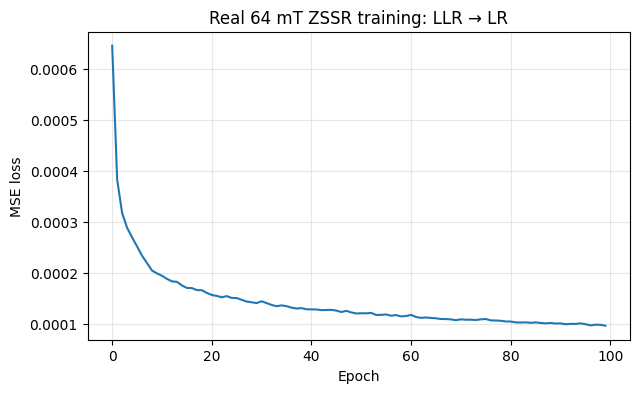

In [33]:
lf_model.train()

for epoch in range(EPOCHS):

    running_loss = 0.0

    for xb, yb in lf_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        lf_optimizer.zero_grad()

        prediction = lf_model(xb)

        loss = lf_criterion(prediction, yb)

        loss.backward()
        lf_optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(lf_loader.dataset)
    lf_loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"64 mT internal MSE: {epoch_loss:.6f}"
        )

plt.figure(figsize=(7, 4))
plt.plot(lf_loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Real 64 mT ZSSR training: LLR → LR")
plt.grid(alpha=0.3)
plt.show()


# Module 17 — Real 64 mT inference

Now apply the model to the original real 64 mT LR slice:

```text
64 mT LR
   ↓
trained 64 mT ZSSR CNN
   ↓
64 mT ZSSR-SR
```

This is the actual low-field MRI application.


In [34]:
lf_zssr_sr = zssr_inference(
    lf_model,
    lf_lr,
    scale=SCALE
)

lf_bicubic_sr = upsample(
    lf_lr,
    lf_zssr_sr.shape,
    order=3
)

print("64 mT LR:", lf_lr.shape)
print("64 mT Bicubic SR:", lf_bicubic_sr.shape)
print("64 mT ZSSR SR:", lf_zssr_sr.shape)


64 mT LR: (112, 112)
64 mT Bicubic SR: (224, 224)
64 mT ZSSR SR: (224, 224)


# Module 18 — Real 64 mT visual comparison

For the real low-field experiment we compare:

- Original 64 mT LR
- Bicubic upsampling
- ZSSR output

At this point, do **not** claim that ZSSR is objectively better from visual sharpness alone.

Look for:

- anatomical preservation
- noise amplification
- ringing
- oversharpening
- artificial structures
- consistency of tissue boundaries


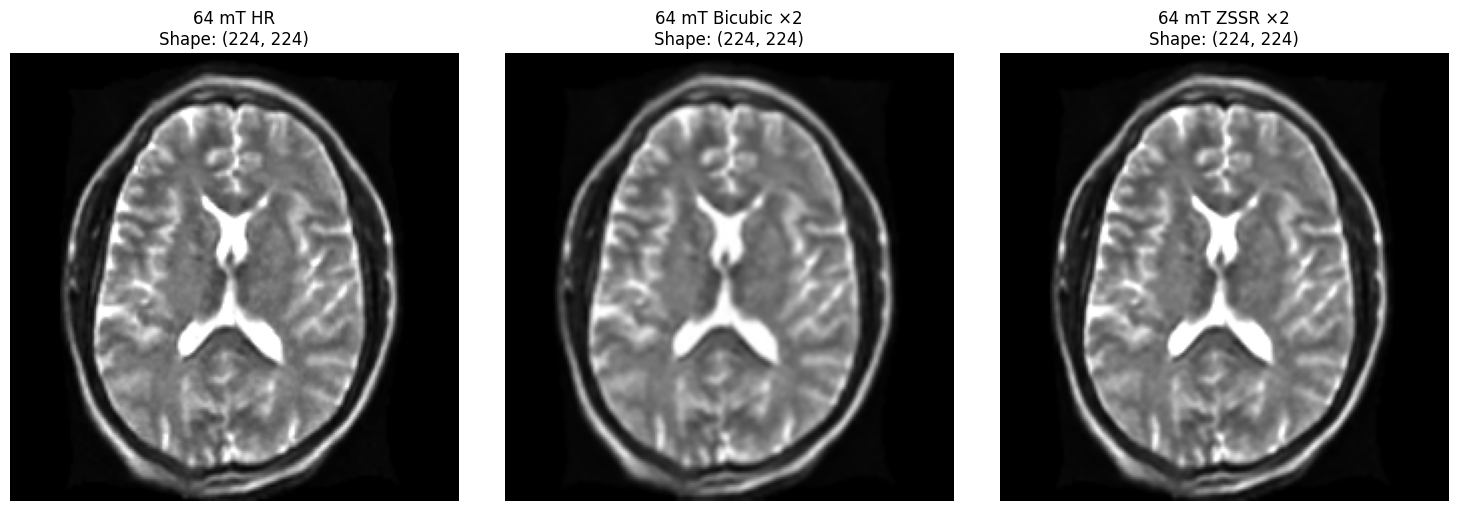

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(lf_hr.T, cmap="gray", origin="lower")
axes[0].set_title(
    f"64 mT HR\n"
    f"Shape: {lf_hr.shape}"
)

axes[1].imshow(lf_bicubic_sr.T, cmap="gray", origin="lower")
axes[1].set_title(
    f"64 mT Bicubic ×2\n"
    f"Shape: {lf_bicubic_sr.shape}"
)

axes[2].imshow(lf_zssr_sr.T, cmap="gray", origin="lower")
axes[2].set_title(
    f"64 mT ZSSR ×2\n"
    f"Shape: {lf_zssr_sr.shape}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

CONTROLLED HR → LR → SR RESULTS
Bicubic : PSNR = 33.736 dB | SSIM = 0.9837
ZSSR    : PSNR = 42.445 dB | SSIM = 0.9954
Δ PSNR  : +8.710 dB
Δ SSIM  : +0.0118


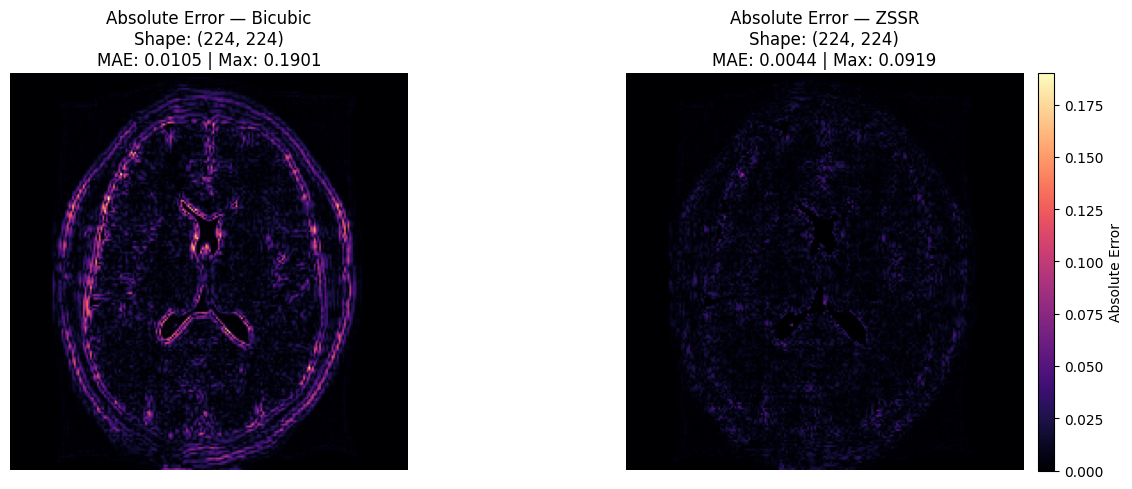

In [36]:
lf_psnr_zssr = peak_signal_noise_ratio(
    lf_hr,
    lf_zssr_sr,
    data_range=1.0
)

lf_ssim_zssr = structural_similarity(
    lf_hr,
    lf_zssr_sr,
    data_range=1.0
)

lf_psnr_bicubic = peak_signal_noise_ratio(
    lf_hr,
    lf_bicubic_sr,
    data_range=1.0
)

lf_ssim_bicubic = structural_similarity(
    lf_hr,
    lf_bicubic_sr,
    data_range=1.0
)

print("=" * 60)
print("CONTROLLED HR → LR → SR RESULTS")
print("=" * 60)
print(f"Bicubic : PSNR = {lf_psnr_bicubic:.3f} dB | SSIM = {lf_ssim_bicubic:.4f}")
print(f"ZSSR    : PSNR = {lf_psnr_zssr:.3f} dB | SSIM = {lf_ssim_zssr:.4f}")
print(f"Δ PSNR  : {lf_psnr_zssr - lf_psnr_bicubic:+.3f} dB")
print(f"Δ SSIM  : {lf_ssim_zssr - lf_ssim_bicubic:+.4f}")

from mpl_toolkits.axes_grid1 import make_axes_locatable

error_bicubic = np.abs(lf_hr - lf_bicubic_sr)
error_zssr = np.abs(lf_hr - lf_zssr_sr)

# Common scale for fair comparison
vmax = max(error_bicubic.max(), error_zssr.max())

# Summary statistics
mae_bicubic = np.mean(error_bicubic)
mae_zssr = np.mean(error_zssr)

max_bicubic = np.max(error_bicubic)
max_zssr = np.max(error_zssr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Bicubic error
# ---------------------------------------------------------

im0 = axes[0].imshow(
    error_bicubic.T,
    cmap="magma",
    origin="lower",
    vmin=0,
    vmax=vmax
)

axes[0].set_title(
    f"Absolute Error — Bicubic\n"
    f"Shape: {error_bicubic.shape}\n"
    f"MAE: {mae_bicubic:.4f} | Max: {max_bicubic:.4f}"
)

axes[0].axis("off")


# ---------------------------------------------------------
# ZSSR error
# ---------------------------------------------------------

im1 = axes[1].imshow(
    error_zssr.T,
    cmap="magma",
    origin="lower",
    vmin=0,
    vmax=vmax
)

axes[1].set_title(
    f"Absolute Error — ZSSR\n"
    f"Shape: {error_zssr.shape}\n"
    f"MAE: {mae_zssr:.4f} | Max: {max_zssr:.4f}"
)

axes[1].axis("off")


# ---------------------------------------------------------
# Dedicated colorbar axis
# ---------------------------------------------------------

divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.15
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label("Absolute Error")


plt.tight_layout()
plt.show()

# Module 19 — Optional 3T reference comparison

If the 3T and 64 mT scans are properly:

- oriented,
- spatially aligned,
- registered,
- matched in field of view,
- and appropriately harmonized,

then the 3T image can be used as a **reference for evaluation**.

However, the 3T image must not silently become the training target in the ZSSR experiment.

### Important distinction

**Training:**

```text
64 mT LLR → 64 mT LR
```

**Evaluation, if scientifically valid:**

```text
64 mT ZSSR-SR ↔ registered 3T reference
```

Without a valid reference relationship, PSNR and SSIM between separate 64 mT and 3T acquisitions can be misleading.


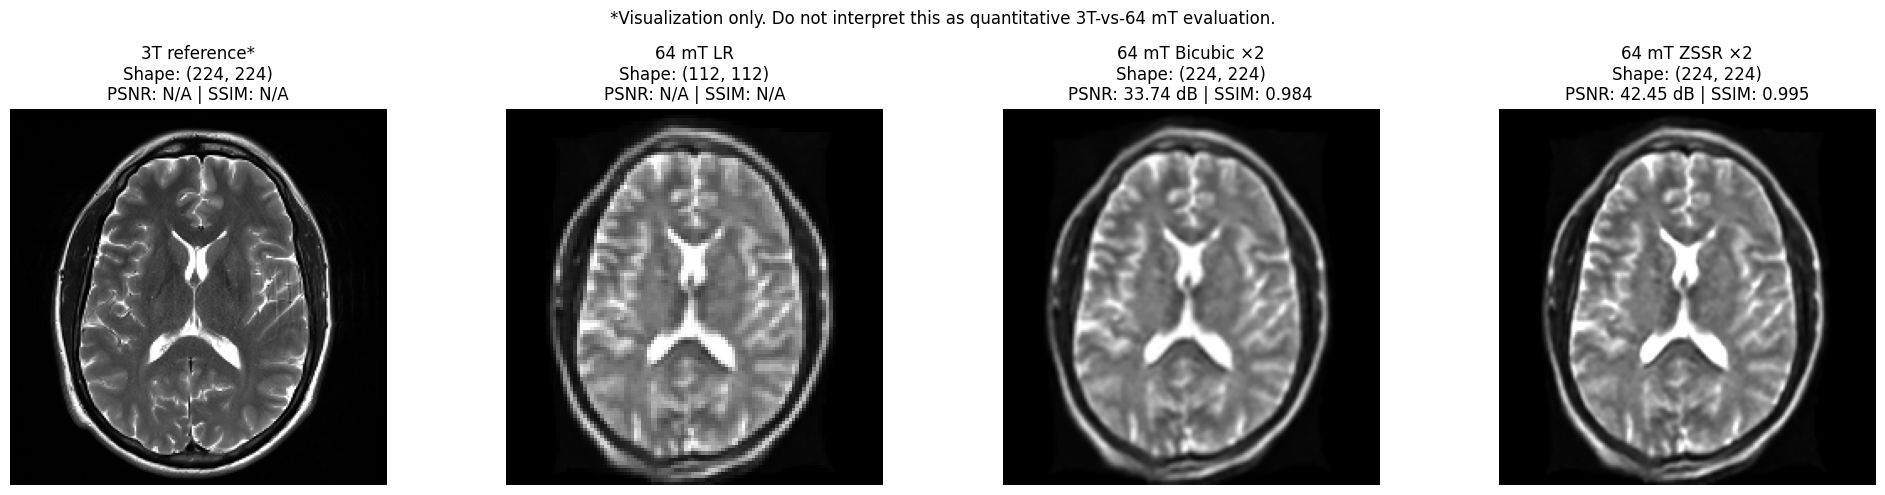

In [37]:
# ---------------------------------------------------------
# 3T reference for visualization only
# ---------------------------------------------------------

reference_3T_for_display = resize(
    mri_3T_n[:, :, SLICE_INDEX],
    lf_zssr_sr.shape,
    order=3,
    mode="reflect",
    anti_aliasing=False,
    preserve_range=True
).astype(np.float32)


# ---------------------------------------------------------
# Quantitative metrics
# Compare 64 mT reconstructions against the
# original 224 x 224 64 mT reference (lf_hr)
# ---------------------------------------------------------

psnr_lf_bicubic = peak_signal_noise_ratio(
    lf_hr,
    lf_bicubic_sr,
    data_range=1.0
)

ssim_lf_bicubic = structural_similarity(
    lf_hr,
    lf_bicubic_sr,
    data_range=1.0
)

psnr_lf_zssr = peak_signal_noise_ratio(
    lf_hr,
    lf_zssr_sr,
    data_range=1.0
)

ssim_lf_zssr = structural_similarity(
    lf_hr,
    lf_zssr_sr,
    data_range=1.0
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(20, 5))


# 3T reference
axes[0].imshow(
    reference_3T_for_display.T,
    cmap="gray",
    origin="lower"
)

axes[0].set_title(
    f"3T reference*\n"
    f"Shape: {reference_3T_for_display.shape}\n"
    f"PSNR: N/A | SSIM: N/A"
)


# 64 mT LR
axes[1].imshow(
    lf_lr.T,
    cmap="gray",
    origin="lower"
)

axes[1].set_title(
    f"64 mT LR\n"
    f"Shape: {lf_lr.shape}\n"
    f"PSNR: N/A | SSIM: N/A"
)


# 64 mT Bicubic
axes[2].imshow(
    lf_bicubic_sr.T,
    cmap="gray",
    origin="lower"
)

axes[2].set_title(
    f"64 mT Bicubic ×2\n"
    f"Shape: {lf_bicubic_sr.shape}\n"
    f"PSNR: {psnr_lf_bicubic:.2f} dB | "
    f"SSIM: {ssim_lf_bicubic:.3f}"
)


# 64 mT ZSSR
axes[3].imshow(
    lf_zssr_sr.T,
    cmap="gray",
    origin="lower"
)

axes[3].set_title(
    f"64 mT ZSSR ×2\n"
    f"Shape: {lf_zssr_sr.shape}\n"
    f"PSNR: {psnr_lf_zssr:.2f} dB | "
    f"SSIM: {ssim_lf_zssr:.3f}"
)


for ax in axes:
    ax.axis("off")


plt.suptitle(
    "*Visualization only. Do not interpret this as quantitative "
    "3T-vs-64 mT evaluation.\n",
    fontsize=12
)

plt.tight_layout()
plt.show()

# Module 20 — Suggested ZSSR improvements

Now students can change one component at a time.

| Experiment | Modification | Question |
|---|---|---|
| Baseline | CNN + MSE | How does basic ZSSR compare with bicubic? |
| 1 | L1 loss | Does L1 preserve structures differently? |
| 2 | More CNN layers | Does capacity improve the result? |
| 3 | More patches | Does internal training benefit? |
| 4 | Different patch size | What spatial context works best? |
| 5 | Learning-rate tuning | How does optimization affect convergence? |
| 6 | More internal scales | Does multi-scale training help? |
| 7 | Different degradation kernel | How sensitive is ZSSR to the assumed degradation? |
| 8 | Data augmentation | Does rotation/flipping improve stability? |
| 9 | Residual vs direct prediction | Which formulation is easier to optimize? |

For every experiment record:

- PSNR
- SSIM
- training time
- visual appearance
- artifacts


# Module 21 — Extension from one slice to a volume

The next notebook can automate the real 64 mT workflow:

```text
64 mT NIfTI volume
       │
       ▼
   slice 1 ──→ ZSSR ──→ SR slice 1
   slice 2 ──→ ZSSR ──→ SR slice 2
   slice 3 ──→ ZSSR ──→ SR slice 3
       ...
   slice N ──→ ZSSR ──→ SR slice N
       │
       ▼
reconstruct SR NIfTI volume
```

### Important limitation

Slice-wise 2D ZSSR does not use neighboring slices. Therefore it can create slice-to-slice variation.

This motivates three progressively more advanced approaches:

### 1. Slice-wise 2D ZSSR

Simple and computationally inexpensive.

### 2. 2.5D ZSSR

Use neighboring slices:

```text
slice k-1 ─┐
slice k   ─┼→ CNN → SR slice k
slice k+1 ─┘
```

### 3. Full 3D ZSSR

Use 3D patches and `Conv3d`:

```text
3D LLR patch
      ↓
   3D CNN
      ↓
3D LR patch
```

For the workshop, the recommended progression is:

**2D → slice-wise volume → 2.5D → full 3D**


# Module 23 — Final student checklist

Students should be able to answer these questions before moving to the next notebook.

### Concept

- What is zero-shot super-resolution?
- Why can one image provide its own training examples?
- What are HR, LR, and LLR?
- What does the CNN actually learn?

### Controlled experiment

- Why do we start with a known 3T HR image?
- Why do we create 112 × 112 LR from 224 × 224 HR?
- Why do we create 56 × 56 LLR?
- Why is the CNN trained on LLR → LR but applied to LR → HR?

### Evaluation

- Why is bicubic a useful baseline?
- What do PSNR and SSIM measure?
- Why is a valid HR reference required?

### Real LF-MRI

- What is different about a true 64 mT slice?
- Why is the 3T image not the ZSSR training target?
- When can 3T be used for PSNR/SSIM evaluation?
- What artifacts should be inspected before claiming improvement?

### 3D

- Why can independent slice-wise ZSSR produce inconsistency?
- What is 2.5D ZSSR?
- What changes when using a full 3D CNN?

---

# Final takeaway

The notebook follows one consistent idea:

```text
                CONTROLLED EXPERIMENT
                =====================

3T HR 224×224
     │
     └── ×2 downsample
             ↓
         LR 112×112
             │
             └── ×2 downsample
                     ↓
                 LLR 56×56
                     │
                     ▼
               Train CNN
                LLR → LR
                     │
                     ▼
              Apply to LR
                LR → HR
                     │
                     ▼
             Compare with HR
          Bicubic vs ZSSR
          PSNR + SSIM


                REAL LF-MRI
                ===========

64 mT real slice
       │
       ▼
   real LR
       │
       └── ×2 downsample
               ↓
          64 mT LLR
               │
               ▼
         Train fresh CNN
          LLR → real LR
               │
               ▼
      Apply CNN to real LR
               │
               ▼
        64 mT ZSSR-SR
               │
               ▼
   Optional reference evaluation
          against 3T*

*only after valid registration/
 harmonization/reference setup
```

#Extend 2D idea to 3D volumes
      
      For your 64 mT volume:

      Original 64 mT reference volume
      224 × 224 × 160
              │
              ├── extract 160 axial slices
              │
              ├── each slice: 224 × 224
              │
              ▼
      synthetically downsample each slice ×2
              │
              ▼
      LR slices: 112 × 112
              │
              ├── Bicubic → 224 × 224
              │
              └── 2D ZSSR → 224 × 224
                      │
                      ▼
              reconstructed volume
              224 × 224 × 160
                      │
                      ▼
          compare with original volume
          PSNR + SSIM

In [ ]:
lf_volume_hr = mri_64mT_n.astype(np.float32)

print(lf_volume_hr.shape)
# (224, 224, 160)

(224, 224, 160)


In [ ]:
from skimage.transform import resize
import numpy as np

SCALE = 2

lf_volume_lr = resize(
    lf_volume_hr,
    (
        lf_volume_hr.shape[0] // SCALE,
        lf_volume_hr.shape[1] // SCALE,
        lf_volume_hr.shape[2]
    ),
    order=1,
    mode="reflect",
    anti_aliasing=True,
    preserve_range=True
).astype(np.float32)

print("HR volume:", lf_volume_hr.shape)
print("LR volume:", lf_volume_lr.shape)

HR volume: (224, 224, 160)
LR volume: (112, 112, 160)


    2. Build the 2D ZSSR training dataset

    For each LR slice, create its own internal ZSSR training pair.

    For example:

    Observed LR slice
    112 × 112
          │
          ▼
    internal downsample
    56 × 56
          │
          ▼
    ZSSR training
    56 × 56 → 112 × 112



In [ ]:
def create_zssr_pairs_from_volume(
    hr_volume,
    scale=2,
    order=1
):
    X = []
    Y = []

    for z in range(hr_volume.shape[2]):

        hr_slice = hr_volume[:, :, z]

        # Create observed LR slice
        lr_slice = resize(
            hr_slice,
            (
                hr_slice.shape[0] // scale,
                hr_slice.shape[1] // scale
            ),
            order=order,
            mode="reflect",
            anti_aliasing=True,
            preserve_range=True
        ).astype(np.float32)

        # Internal degradation for ZSSR
        lr_internal = resize(
            lr_slice,
            (
                lr_slice.shape[0] // scale,
                lr_slice.shape[1] // scale
            ),
            order=order,
            mode="reflect",
            anti_aliasing=True,
            preserve_range=True
        ).astype(np.float32)

        X.append(lr_internal)
        Y.append(lr_slice)

    return np.stack(X), np.stack(Y)

In [ ]:
X_volume, Y_volume = create_zssr_pairs_from_volume(
    lf_volume_hr,
    scale=2
)

print("ZSSR input:", X_volume.shape)
print("ZSSR target:", Y_volume.shape)

ZSSR input: (160, 56, 56)
ZSSR target: (160, 112, 112)


    3. Train your existing 2D ZSSR network

    You can use the same 2D model you already built.

    Convert the slices to PyTorch:

In [ ]:
X_tensor = torch.from_numpy(X_volume).unsqueeze(1)
Y_tensor = torch.from_numpy(Y_volume).unsqueeze(1)

print(X_tensor.shape)
print(Y_tensor.shape)

torch.Size([160, 1, 56, 56])
torch.Size([160, 1, 112, 112])


In [ ]:

from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, Y_tensor)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = model.to(device)

Using device: cuda


In [ ]:
num_epochs = 100

model.train()

for epoch in range(num_epochs):

    epoch_loss = 0.0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        prediction = model(x)

        loss = criterion(prediction, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {epoch_loss:.6f}"
        )

Epoch [10/100] Loss: 0.000555
Epoch [20/100] Loss: 0.000522
Epoch [30/100] Loss: 0.000503
Epoch [40/100] Loss: 0.000485
Epoch [50/100] Loss: 0.000472
Epoch [60/100] Loss: 0.000463
Epoch [70/100] Loss: 0.000452
Epoch [80/100] Loss: 0.000444
Epoch [90/100] Loss: 0.000436
Epoch [100/100] Loss: 0.000430


In [ ]:
model.eval()

zssr_volume = np.zeros_like(
    lf_volume_hr,
    dtype=np.float32
)

with torch.no_grad():

    for z in range(lf_volume_lr.shape[2]):

        lr_slice = lf_volume_lr[:, :, z]

        x = torch.from_numpy(
            lr_slice
        ).unsqueeze(0).unsqueeze(0).to(device)

        sr = model(x)

        sr = sr.squeeze().cpu().numpy()

        zssr_volume[:, :, z] = sr

In [ ]:
print("ZSSR volume:", zssr_volume.shape)

ZSSR volume: (224, 224, 160)


In [ ]:
# 5. Generate the volume-wide bicubic baseline

# Do exactly the same thing without the learned model:

bicubic_volume = np.zeros_like(
    lf_volume_hr,
    dtype=np.float32
)

for z in range(lf_volume_lr.shape[2]):

    bicubic_volume[:, :, z] = resize(
        lf_volume_lr[:, :, z],
        lf_volume_hr[:, :, z].shape,
        order=3,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True
    ).astype(np.float32)

In [ ]:
# 6. Slice-wise SSIM

# Calculate SSIM for every slice.

from skimage.metrics import structural_similarity

ssim_bicubic = []
ssim_zssr = []

for z in range(lf_volume_hr.shape[2]):

    reference = lf_volume_hr[:, :, z]

    bicubic = bicubic_volume[:, :, z]
    zssr = zssr_volume[:, :, z]

    ssim_b = structural_similarity(
        reference,
        bicubic,
        data_range=1.0
    )

    ssim_z = structural_similarity(
        reference,
        zssr,
        data_range=1.0
    )

    ssim_bicubic.append(ssim_b)
    ssim_zssr.append(ssim_z)

ssim_bicubic = np.array(ssim_bicubic)
ssim_zssr = np.array(ssim_zssr)

In [ ]:
print(
    f"Mean slice SSIM — Bicubic: "
    f"{ssim_bicubic.mean():.4f}"
)

print(
    f"Mean slice SSIM — ZSSR: "
    f"{ssim_zssr.mean():.4f}"
)

Mean slice SSIM — Bicubic: 0.9884
Mean slice SSIM — ZSSR: 0.9933


In [ ]:
# 7. Volume-level SSIM

# You can also calculate a single SSIM over the whole volume.

# Depending on your installed skimage version:

ssim_bicubic_volume = structural_similarity(
    lf_volume_hr,
    bicubic_volume,
    data_range=1.0,
    channel_axis=None
)

ssim_zssr_volume = structural_similarity(
    lf_volume_hr,
    zssr_volume,
    data_range=1.0,
    channel_axis=None
)

print(
    f"Volume SSIM — Bicubic: "
    f"{ssim_bicubic_volume:.4f}"
)

print(
    f"Volume SSIM — ZSSR: "
    f"{ssim_zssr_volume:.4f}"
)

Volume SSIM — Bicubic: 0.9902
Volume SSIM — ZSSR: 0.9945


In [ ]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio
import numpy as np

ssim_bicubic = []
ssim_zssr = []
psnr_bicubic = []
psnr_zssr = []
mae_bicubic = []
mae_zssr = []

for z in range(lf_volume_hr.shape[2]):

    reference = lf_volume_hr[:, :, z]
    bicubic = bicubic_volume[:, :, z]
    zssr = zssr_volume[:, :, z]

    # SSIM
    ssim_bicubic.append(
        structural_similarity(reference, bicubic, data_range=1.0)
    )
    ssim_zssr.append(
        structural_similarity(reference, zssr, data_range=1.0)
    )

    # PSNR
    psnr_bicubic.append(
        peak_signal_noise_ratio(reference, bicubic, data_range=1.0)
    )
    psnr_zssr.append(
        peak_signal_noise_ratio(reference, zssr, data_range=1.0)
    )

    # MAE
    mae_bicubic.append(np.mean(np.abs(reference - bicubic)))
    mae_zssr.append(np.mean(np.abs(reference - zssr)))

ssim_bicubic = np.array(ssim_bicubic)
ssim_zssr = np.array(ssim_zssr)

psnr_bicubic = np.array(psnr_bicubic)
psnr_zssr = np.array(psnr_zssr)

mae_bicubic = np.array(mae_bicubic)
mae_zssr = np.array(mae_zssr)

/usr/local/lib/python3.13/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


In [ ]:
print("Bicubic")
print("Mean SSIM:", ssim_bicubic.mean())
print("Mean PSNR:", psnr_bicubic.mean())
print("Mean MAE :", mae_bicubic.mean())

print("\n2D ZSSR")
print("Mean SSIM:", ssim_zssr.mean())
print("Mean PSNR:", psnr_zssr.mean())
print("Mean MAE :", mae_zssr.mean())

Bicubic
Mean SSIM: 0.9883729630088925
Mean PSNR: inf
Mean MAE : 0.007242141

2D ZSSR
Mean SSIM: 0.9933111173284725
Mean PSNR: 40.81053460885484
Mean MAE : 0.005078015


In [ ]:
finite_bicubic = np.isfinite(psnr_bicubic)

print("Total slices:", len(psnr_bicubic))
print("Finite PSNR slices:", finite_bicubic.sum())
print("Infinite PSNR slices:", (~finite_bicubic).sum())

print("\nInfinite slice indices:")
print(np.where(~finite_bicubic)[0])

Total slices: 160
Finite PSNR slices: 159
Infinite PSNR slices: 1

Infinite slice indices:
[159]


In [ ]:
# ============================================================
# COMPLETE VOLUME METRICS — BICUBIC vs 2D ZSSR
# Handles infinite PSNR slices safely
# ============================================================

import numpy as np
import pandas as pd
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# ------------------------------------------------------------
# 1. Make sure volumes are float32
# ------------------------------------------------------------

reference_volume = lf_volume_hr.astype(np.float32)
bicubic_volume_eval = bicubic_volume.astype(np.float32)
zssr_volume_eval = zssr_volume.astype(np.float32)

print("Reference volume:", reference_volume.shape)
print("Bicubic volume: ", bicubic_volume_eval.shape)
print("ZSSR volume:    ", zssr_volume_eval.shape)


# ------------------------------------------------------------
# 2. Calculate slice-wise metrics
# ------------------------------------------------------------

ssim_bicubic = []
ssim_zssr = []

psnr_bicubic = []
psnr_zssr = []

mae_bicubic = []
mae_zssr = []

N = reference_volume.shape[2]

for z in range(N):

    reference = reference_volume[:, :, z]
    bicubic = bicubic_volume_eval[:, :, z]
    zssr = zssr_volume_eval[:, :, z]

    # -------------------------
    # SSIM
    # -------------------------

    ssim_b = structural_similarity(
        reference,
        bicubic,
        data_range=1.0
    )

    ssim_z = structural_similarity(
        reference,
        zssr,
        data_range=1.0
    )

    # -------------------------
    # PSNR
    # -------------------------

    psnr_b = peak_signal_noise_ratio(
        reference,
        bicubic,
        data_range=1.0
    )

    psnr_z = peak_signal_noise_ratio(
        reference,
        zssr,
        data_range=1.0
    )

    # -------------------------
    # MAE
    # -------------------------

    mae_b = np.mean(
        np.abs(reference - bicubic)
    )

    mae_z = np.mean(
        np.abs(reference - zssr)
    )

    ssim_bicubic.append(ssim_b)
    ssim_zssr.append(ssim_z)

    psnr_bicubic.append(psnr_b)
    psnr_zssr.append(psnr_z)

    mae_bicubic.append(mae_b)
    mae_zssr.append(mae_z)


# Convert to NumPy arrays

ssim_bicubic = np.array(ssim_bicubic)
ssim_zssr = np.array(ssim_zssr)

psnr_bicubic = np.array(psnr_bicubic)
psnr_zssr = np.array(psnr_zssr)

mae_bicubic = np.array(mae_bicubic)
mae_zssr = np.array(mae_zssr)


# ------------------------------------------------------------
# 3. Handle infinite PSNR
# ------------------------------------------------------------
#
# An infinite PSNR means MSE = 0.
# This is a valid mathematical result.
#
# We exclude it ONLY when calculating the mean slice PSNR.
# ------------------------------------------------------------

finite_bicubic = np.isfinite(psnr_bicubic)
finite_zssr = np.isfinite(psnr_zssr)

mean_psnr_bicubic = np.mean(
    psnr_bicubic[finite_bicubic]
)

mean_psnr_zssr = np.mean(
    psnr_zssr[finite_zssr]
)

infinite_bicubic_slices = np.where(
    ~finite_bicubic
)[0]

infinite_zssr_slices = np.where(
    ~finite_zssr
)[0]


# ------------------------------------------------------------
# 4. Mean slice SSIM and MAE
# ------------------------------------------------------------

mean_ssim_bicubic = np.mean(
    ssim_bicubic
)

mean_ssim_zssr = np.mean(
    ssim_zssr
)

mean_mae_bicubic = np.mean(
    mae_bicubic
)

mean_mae_zssr = np.mean(
    mae_zssr
)


# ------------------------------------------------------------
# 5. FULL-VOLUME METRICS
# ------------------------------------------------------------

volume_psnr_bicubic = peak_signal_noise_ratio(
    reference_volume,
    bicubic_volume_eval,
    data_range=1.0
)

volume_psnr_zssr = peak_signal_noise_ratio(
    reference_volume,
    zssr_volume_eval,
    data_range=1.0
)


volume_ssim_bicubic = structural_similarity(
    reference_volume,
    bicubic_volume_eval,
    data_range=1.0,
    channel_axis=None
)

volume_ssim_zssr = structural_similarity(
    reference_volume,
    zssr_volume_eval,
    data_range=1.0,
    channel_axis=None
)


volume_mae_bicubic = np.mean(
    np.abs(
        reference_volume -
        bicubic_volume_eval
    )
)

volume_mae_zssr = np.mean(
    np.abs(
        reference_volume -
        zssr_volume_eval
    )
)


# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("             64 mT VOLUME RECONSTRUCTION RESULTS")
print("=" * 65)

print("\n--- VOLUME-LEVEL METRICS ---")

print(
    f"\nBicubic:"
    f"\n  PSNR : {volume_psnr_bicubic:.4f} dB"
    f"\n  SSIM : {volume_ssim_bicubic:.6f}"
    f"\n  MAE  : {volume_mae_bicubic:.6f}"
)

print(
    f"\n2D ZSSR:"
    f"\n  PSNR : {volume_psnr_zssr:.4f} dB"
    f"\n  SSIM : {volume_ssim_zssr:.6f}"
    f"\n  MAE  : {volume_mae_zssr:.6f}"
)


print("\n")
print("--- MEAN SLICE-WISE METRICS ---")

print(
    f"\nBicubic:"
    f"\n  Mean PSNR : {mean_psnr_bicubic:.4f} dB"
    f"\n  Mean SSIM : {mean_ssim_bicubic:.6f}"
    f"\n  Mean MAE  : {mean_mae_bicubic:.6f}"
)

print(
    f"\n2D ZSSR:"
    f"\n  Mean PSNR : {mean_psnr_zssr:.4f} dB"
    f"\n  Mean SSIM : {mean_ssim_zssr:.6f}"
    f"\n  Mean MAE  : {mean_mae_zssr:.6f}"
)


# ------------------------------------------------------------
# 7. INFINITE PSNR INFORMATION
# ------------------------------------------------------------

print("\n")
print("--- INFINITE PSNR CHECK ---")

print(
    "Bicubic infinite-PSNR slices:",
    infinite_bicubic_slices
)

print(
    "Number of Bicubic infinite slices:",
    len(infinite_bicubic_slices)
)

print(
    "ZSSR infinite-PSNR slices:",
    infinite_zssr_slices
)

print(
    "Number of ZSSR infinite slices:",
    len(infinite_zssr_slices)
)


# ------------------------------------------------------------
# 8. IMPROVEMENT
# ------------------------------------------------------------

ssim_change = (
    volume_ssim_zssr -
    volume_ssim_bicubic
)

psnr_change = (
    volume_psnr_zssr -
    volume_psnr_bicubic
)

mae_reduction_percent = (
    (volume_mae_bicubic -
     volume_mae_zssr)
    / volume_mae_bicubic
) * 100


print("\n")
print("--- ZSSR vs BICUBIC ---")

print(
    f"Volume SSIM change : "
    f"{ssim_change:+.6f}"
)

print(
    f"Volume PSNR change : "
    f"{psnr_change:+.4f} dB"
)

print(
    f"Volume MAE reduction: "
    f"{mae_reduction_percent:+.2f}%"
)


# ------------------------------------------------------------
# 9. FINAL SUMMARY TABLE
# ------------------------------------------------------------

results = pd.DataFrame({

    "Method": [
        "Bicubic",
        "2D ZSSR"
    ],

    "Volume PSNR (dB)": [
        volume_psnr_bicubic,
        volume_psnr_zssr
    ],

    "Volume SSIM": [
        volume_ssim_bicubic,
        volume_ssim_zssr
    ],

    "Volume MAE": [
        volume_mae_bicubic,
        volume_mae_zssr
    ],

    "Mean Slice PSNR (dB)": [
        mean_psnr_bicubic,
        mean_psnr_zssr
    ],

    "Mean Slice SSIM": [
        mean_ssim_bicubic,
        mean_ssim_zssr
    ],

    "Mean Slice MAE": [
        mean_mae_bicubic,
        mean_mae_zssr
    ]
})


print("\n")
print("=" * 65)
print("                    FINAL TABLE")
print("=" * 65)

display(
    results.round(6)
)

Reference volume: (224, 224, 160)
Bicubic volume:  (224, 224, 160)
ZSSR volume:     (224, 224, 160)


/usr/local/lib/python3.13/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


In [ ]:
# ============================================================
# FINAL VISUAL COMPARISON
# HF / 3T vs 64 mT Reference vs Bicubic vs 2D ZSSR
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import resize
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# ------------------------------------------------------------
# Select slice
# ------------------------------------------------------------

z = 80   # change to any slice, e.g. 80

# ------------------------------------------------------------
# 64 mT reference slice
# ------------------------------------------------------------

lf_ref = reference_volume[:, :, z]

# ------------------------------------------------------------
# 64 mT LR slice
# ------------------------------------------------------------

lf_lr_display = lf_volume_lr[:, :, z]

# ------------------------------------------------------------
# Bicubic reconstruction
# ------------------------------------------------------------

lf_bicubic_display = bicubic_volume_eval[:, :, z]

# ------------------------------------------------------------
# 2D ZSSR reconstruction
# ------------------------------------------------------------

lf_zssr_display = zssr_volume_eval[:, :, z]

# ------------------------------------------------------------
# HF / 3T slice
#
# Resize only for display so it matches the 64 mT image size.
# ------------------------------------------------------------

hf_slice = mri_3T_n[:, :, SLICE_INDEX].astype(np.float32)

hf_slice_display = resize(
    hf_slice,
    lf_ref.shape,
    order=3,
    mode="reflect",
    anti_aliasing=False,
    preserve_range=True
).astype(np.float32)


# ============================================================
# METRICS
# ============================================================

# Bicubic
psnr_bicubic_display = peak_signal_noise_ratio(
    lf_ref,
    lf_bicubic_display,
    data_range=1.0
)

ssim_bicubic_display = structural_similarity(
    lf_ref,
    lf_bicubic_display,
    data_range=1.0
)


# 2D ZSSR
psnr_zssr_display = peak_signal_noise_ratio(
    lf_ref,
    lf_zssr_display,
    data_range=1.0
)

ssim_zssr_display = structural_similarity(
    lf_ref,
    lf_zssr_display,
    data_range=1.0
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5)
)


# ------------------------------------------------------------
# 1. HF / 3T
# ------------------------------------------------------------

axes[0].imshow(
    hf_slice_display.T,
    cmap="gray",
    origin="lower"
)

axes[0].set_title(
    f"HF / 3T\n"
    f"Shape: {hf_slice_display.shape}\n"
    f"PSNR: N/A | SSIM: N/A"
)


# ------------------------------------------------------------
# 2. 64 mT Reference
# ------------------------------------------------------------

axes[1].imshow(
    lf_ref.T,
    cmap="gray",
    origin="lower"
)

axes[1].set_title(
    f"64 mT Reference\n"
    f"Shape: {lf_ref.shape}\n"
    f"PSNR: N/A | SSIM: N/A"
)


# ------------------------------------------------------------
# 3. Bicubic
# ------------------------------------------------------------

axes[2].imshow(
    lf_bicubic_display.T,
    cmap="gray",
    origin="lower"
)

axes[2].set_title(
    f"Bicubic\n"
    f"Shape: {lf_bicubic_display.shape}\n"
    f"PSNR: {psnr_bicubic_display:.2f} dB | "
    f"SSIM: {ssim_bicubic_display:.4f}"
)


# ------------------------------------------------------------
# 4. 2D ZSSR
# ------------------------------------------------------------

axes[3].imshow(
    lf_zssr_display.T,
    cmap="gray",
    origin="lower"
)

axes[3].set_title(
    f"2D ZSSR\n"
    f"Shape: {lf_zssr_display.shape}\n"
    f"PSNR: {psnr_zssr_display:.2f} dB | "
    f"SSIM: {ssim_zssr_display:.4f}"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

for ax in axes:
    ax.axis("off")

fig.suptitle(
    f"64 mT Super-Resolution Comparison — Slice {z} \n",
    fontsize=16
)

plt.tight_layout()
plt.show()